# Dynamic Breakpoint 
-an internal breakpoint
#### Unlike static brakpoint which placed just before or after the node, dynamic breakpoints are placed inside the node.

Two Types:
1. interrupt()
2. NodeInterrupt()
This allows graph dynamically intrrupt itself. This is an internal breakpoint.

Advantages:
1. Conditional logic set by the graph developer
2. User feedback/acceptance- communicate to the user why it's interrupted (by passing whatever you want to the NodeInterrupt).

### Goal: 
1. Create a graph with dynamic breakpoint using **Nodeinterrupt**(deprecciated)
2. Create a graph with dynamic breakpoint using **Interrupt()**

- Create a simple graph that gets interrupted if the user input is longer than 5 characters.

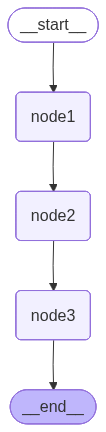

In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.errors import NodeInterrupt

# create state
class DynamicInterrupt_state(TypedDict):
    input: str

# define node functions
def node1(state:DynamicInterrupt_state)->DynamicInterrupt_state:
    print("----node1-----")
    return state

def node2(state:DynamicInterrupt_state)->DynamicInterrupt_state:
    print("-----------node2--------------")
    # raise interrupt error if length of the input character is >5
    if len(state['input'])>5:
        raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")
    return state

def node3(state:DynamicInterrupt_state)->DynamicInterrupt_state:
    print("---------------node3-------------")
    return state

# build graph

builder = StateGraph(DynamicInterrupt_state)

# Add nodes
builder.add_node("node1", node1)
builder.add_node("node2", node2)
builder.add_node("node3", node3)

#Add Edges
builder.set_entry_point("node1")
builder.add_edge('node1','node2')
builder.add_edge('node2','node3')
builder.add_edge('node3',END)

#compile with memory
memory = MemorySaver()

graph =builder.compile(checkpointer=memory)


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))                
    

### Run the graph with characters more than 5

In [7]:
config_thread = {"configurable":{'thread_id': "1" }}

input = "I like to Fly like a Bird!"

result = graph.invoke({'input': input},config_thread)
result

----node1-----
-----------node2--------------


C:\Users\divya\AppData\Local\Temp\ipykernel_34048\4197097278.py:19: LangGraphDeprecatedSinceV10: NodeInterrupt is deprecated. Please use `langgraph.types.interrupt` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")


{'input': 'I like to Fly like a Bird!',
 '__interrupt__': [Interrupt(value='Received input that is longer than 5 characters: I like to Fly like a Bird!', id='placeholder-id')]}

### Find Next node

In [10]:
next_node = graph.get_state(config_thread)
next_node

StateSnapshot(values={'input': 'I like to Fly like a Bird!'}, next=('node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f145059-6f49-68c0-8001-ff199ae69504'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-01T02:29:33.496134+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f145059-6f47-61a9-8000-ebf2d2b2b22b'}}, tasks=(PregelTask(id='2ac6a4dc-ad5c-327a-3763-a6baacb40e8e', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(Interrupt(value='Received input that is longer than 5 characters: I like to Fly like a Bird!', id='placeholder-id'),), state=None, result=None),), interrupts=(Interrupt(value='Received input that is longer than 5 characters: I like to Fly like a Bird!', id='placeholder-id'),))

In [12]:
next_node.next

('node2',)

In [13]:
next_node.tasks

(PregelTask(id='2ac6a4dc-ad5c-327a-3763-a6baacb40e8e', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(Interrupt(value='Received input that is longer than 5 characters: I like to Fly like a Bird!', id='placeholder-id'),), state=None, result=None),)

## Resuming the graph, runs node2 again and makes us get stuck there forever.
- Needs a state update to continue

In [14]:
# run graph without input
graph.invoke(None,config_thread)

-----------node2--------------


C:\Users\divya\AppData\Local\Temp\ipykernel_34048\4197097278.py:19: LangGraphDeprecatedSinceV10: NodeInterrupt is deprecated. Please use `langgraph.types.interrupt` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")


{'input': 'I like to Fly like a Bird!',
 '__interrupt__': [Interrupt(value='Received input that is longer than 5 characters: I like to Fly like a Bird!', id='placeholder-id')]}

## Update the state

In [16]:
graph.update_state(
    config_thread,
    {"input": "hi"},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f145093-1db1-6beb-8002-0d88b6db20fc'}}

In [17]:
result = graph.invoke(None,config_thread)
result 

-----------node2--------------
---------------node3-------------


{'input': 'hi'}

## Build a graph with interrupt() 

##### The interrupt function pauses graph execution and returns a value to the caller. When you call interrupt within a node, LangGraph saves the current graph state and waits for you to resume execution with input.
#### To use interrupt, you need:
- A checkpointer to persist the graph state (use a durable checkpointer in production)
- A thread ID in your config so the runtime knows which state to resume from
- To call interrupt() where you want to pause (payload must be JSON-serializable)

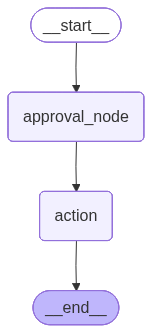

In [5]:
# Define the state
from typing import TypedDict, Optional

class State(TypedDict):
    input:str
    approved: Optional[bool]

# Create a Node That Uses interrupt()
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

def approval_node(state:State):
    # pause exeution for approval
    aprroval = interrupt("Do you want to approive this action?")
    
    #when resumed, aprroval is the return value for approve field
    return {'approved': aprroval }

# continue to the next node
def action(state:State)->State:
    joke = "can eggs crack jokes? NO! they crack each other"
    return {'input': joke }
    

# Build the Graph
builder =StateGraph(State)
memory = InMemorySaver()

# Add nodes
builder.add_node("approval_node" , approval_node)
builder.add_node("action" , action)

# add edges
builder.add_edge(START, "approval_node")
builder.add_edge("approval_node", 'action')
builder.add_edge('action', END)

# compile with memory
graph = builder.compile(checkpointer=memory)

graph


## First Run with threadID — Graph Pauses at interrupt()
#### What happens now:
    - The graph runs approval_node    
    - It hits interrupt("Do you approve this action?")    
    - Execution pauses    
    - State is saved    
    - You get an interrupt back

In [12]:
# create a thread
thread_config = {"configurable": {"thread_id": "4"}}

input_msg = {'input':" Tell me a joke!"}

# invoke graph with streaming values
for chunk in graph.stream(input_msg , thread_config , stream_mode="values", version = 'v2'):
    print(chunk)
    inturrupt = chunk['interrupts']


{'type': 'values', 'ns': (), 'data': {'input': ' Tell me a joke!'}, 'interrupts': ()}
{'type': 'values', 'ns': (), 'data': {'input': ' Tell me a joke!'}, 'interrupts': (Interrupt(value='Do you want to approive this action?', id='616f70b4e696c972494b5227fb0e5af4'),)}


In [13]:
#This means the graph is waiting for your answer.
inturrupt

(Interrupt(value='Do you want to approive this action?', id='616f70b4e696c972494b5227fb0e5af4'),)

### Next node is still approval in the checkpoint as node must return or update the state value

In [14]:
state = graph.get_state(thread_config)
state.next

('approval_node',)

## Resume the Graph With Human Input using Command(resume=True)

### What happens now:
- The graph resumes from the saved checkpoint
- interrupt() returns True
- proceeds to next node

In [10]:
from langgraph.types import Command

for chunk in graph.stream(Command(resume=True) , thread_config , stream_mode="values", version = 'v2'):
    print(chunk)


{'type': 'values', 'ns': (), 'data': {'input': ' Tell me a joke!'}, 'interrupts': ()}
{'type': 'values', 'ns': (), 'data': {'input': ' Tell me a joke!', 'approved': True}, 'interrupts': ()}
{'type': 'values', 'ns': (), 'data': {'input': 'can eggs crack jokes? NO! they crack each other', 'approved': True}, 'interrupts': ()}


## get state

In [11]:
state = graph.get_state(thread_config)
state

StateSnapshot(values={'input': 'can eggs crack jokes? NO! they crack each other', 'approved': True}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f145955-1f3e-6afe-8002-9434e46193b8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-01T19:38:25.257958+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f145955-1f3d-61ac-8001-217a6a166caf'}}, tasks=(), interrupts=())